# Semgrep — RQ3 effect estimation and assessment

This restart-executable notebook retains the legacy developer-only versus developer-plus-third-party reporting-policy treatment and applies the current RQ1 graph assumptions. Association values are kept in the RQ1 result tables and are not printed on the graph.

In [1]:
from pathlib import Path
import sys
from IPython.display import SVG, display

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'causal_analysis').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / 'causal_analysis').is_dir():
    raise RuntimeError('Run this notebook from the ci4security repository')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from causal_analysis.shared.rq3_analysis import run_rq3_analysis

/Users/mkhan04/Desktop/projects/CauSec/ci4security/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


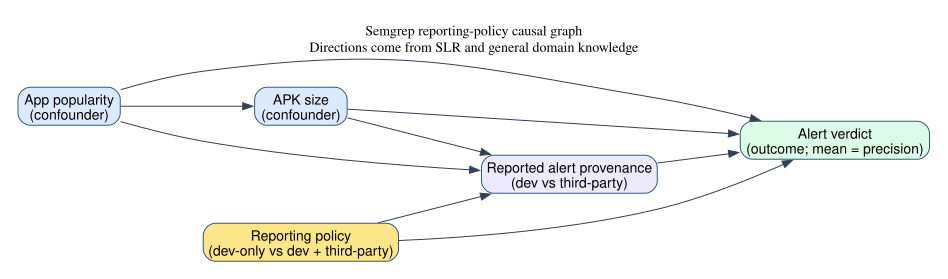

In [2]:
TOOL_NAME = 'Semgrep'
TOOL_SLUG = 'semgrep'
DATA_PATH = REPO_ROOT / 'causal_analysis/data/semgrep/alerts_with_lib_category_and_apk_size_semgrep.csv'
GRAPH_PATH = REPO_ROOT / 'causal_analysis/rq1_graph_assessment/graphs/causal_graph.svg'
OUTPUT_DIR = REPO_ROOT / 'causal_analysis/rq3_effect_estimation/results/semgrep'
BOOTSTRAP_SIMULATIONS = 1000
REFUTER_SIMULATIONS = 200
RANDOM_SEED = 20260918
display(SVG(filename=str(GRAPH_PATH)))

## Run the complete workflow

The workflow evaluates overlap and covariate balance; estimates the alert-row ATE risk difference with PSM, standardized logistic regression, and doubly robust AIPW; compares alert-row and popularity-stratified APK-cluster bootstraps; and runs the four legacy refuters plus an unobserved-common-cause sensitivity scenario.

In [3]:
analysis = run_rq3_analysis(
    tool_name=TOOL_NAME,
    source_path=DATA_PATH,
    graph_path=GRAPH_PATH,
    output_dir=OUTPUT_DIR,
    bootstrap_simulations=BOOTSTRAP_SIMULATIONS,
    refuter_simulations=REFUTER_SIMULATIONS,
    seed=RANDOM_SEED,
)
print(f'Results written to {OUTPUT_DIR}')

Results written to /Users/mkhan04/Desktop/projects/CauSec/ci4security/causal_analysis/rq3_effect_estimation/results/semgrep


In [4]:
display(analysis['overlap'])
display(analysis['balance'])
display(analysis['matching'])
display(analysis['estimator_results'])
display(analysis['refuters'])
display(analysis['software_validation'])

,reporting_policy,reporting_scope,n_rows,ps_min,ps_q01,ps_q05,ps_q25,ps_median,ps_q75,ps_q95,ps_q99,ps_max,common_support_lower,common_support_upper,n_outside_common_support,percent_outside_common_support,n_extreme_ps_below_0_1_or_above_0_9
0,0,developer_only,1760,0.820778,0.821948,0.825655,0.841780,0.881133,0.919850,0.934734,0.936155,0.936568,0.820778,0.936568,0,0.000000,717
1,1,developer_plus_third_party,14590,0.820778,0.823958,0.826165,0.868019,0.904110,0.927187,0.935880,0.936378,0.936741,0.820778,0.936568,13,0.089102,8064


,covariate,smd_before,abs_smd_before,smd_after_psm,abs_smd_after_psm,balanced_after_psm_at_0_1,smd_after_aipw_weighting,abs_smd_after_aipw_weighting,balanced_after_aipw_weighting_at_0_1
0,app_popularity_encoded,0.375012,0.375012,-0.000369,0.000369,True,-0.029505,0.029505,True
1,apk_size_scaled,0.113108,0.113108,-0.000498,0.000498,True,-0.016400,0.016400,True


,n_treated_rows,n_control_rows,common_support_lower,common_support_upper,n_rows_outside_common_support,percent_rows_outside_common_support,matching_with_replacement,unmatched_rows,unique_controls_used_for_att,unique_treated_used_for_atc,...,mean_atc_propensity_distance,max_atc_propensity_distance,diagnostic_logit_caliper_0_2_sd,att_pairs_above_diagnostic_caliper,atc_pairs_above_diagnostic_caliper,treated_effective_sample_size,control_effective_sample_size,aipw_treated_effective_sample_size,aipw_control_effective_sample_size,n_propensity_scores_clipped_at_0_01_or_0_99
0,14590,1760,0.820778,0.936568,13,0.079511,True,0,262,256,...,0.0,0.0,0.075769,0,0,2790.248001,194.14301,14564.664945,1559.646139,0


,estimator,estimator_label,effect_scale,target_units,estimate,row_bootstrap_successes,row_bootstrap_se,row_ci_low,row_ci_high,row_ci_width,row_ci_excludes_zero,cluster_bootstrap_successes,cluster_bootstrap_se,cluster_ci_low,cluster_ci_high,cluster_ci_width,cluster_ci_excludes_zero
0,psm,Propensity-score matching,risk_difference,ate,0.108563,1000,0.026869,0.022543,0.128969,0.106427,True,1000,0.040119,0.025272,0.183128,0.157855,True
1,logistic_regression,Logistic-regression adjustment,risk_difference,ate,0.122356,1000,0.011816,0.099637,0.146241,0.046604,True,1000,0.056862,-0.000217,0.212517,0.212734,False
2,doubly_robust,Doubly robust (AIPW),risk_difference,ate,0.115609,1000,0.012329,0.092136,0.139648,0.047511,True,1000,0.047351,0.010859,0.197594,0.186735,True


,estimator,refuter,result_index,original_effect,refuter_reference_effect,new_effect,absolute_change_from_original,relative_change_from_original,sign_changed_from_original,p_value,refuter_reports_significant_change,status,error
0,psm,random_common_cause,0,0.108563,0.108563,0.108563,1.387779e-17,1.278320e-16,False,1.000,False,success,None
1,psm,placebo_treatment_refuter,0,0.108563,0.108563,-0.014612,1.231749e-01,1.134597e+00,True,0.630,False,success,None
2,psm,data_subset_refuter,0,0.108563,0.108563,0.075119,3.344343e-02,3.080563e-01,False,0.100,False,success,None
3,psm,dummy_outcome_refuter,0,0.108563,0.000000,-0.001348,1.099106e-01,1.012416e+00,True,0.960,False,success,None
4,psm,add_unobserved_common_cause,0,0.108563,0.108563,0.250275,1.417125e-01,1.305352e+00,False,NaN,None,success,None
5,logistic_regression,random_common_cause,0,0.122356,0.122356,0.122371,1.435816e-05,1.173473e-04,False,0.800,False,success,None
6,logistic_regression,placebo_treatment_refuter,0,0.122356,0.122356,-0.001546,1.239024e-01,1.012637e+00,True,0.830,False,success,None
7,logistic_regression,data_subset_refuter,0,0.122356,0.122356,0.122272,8.437753e-05,6.896060e-04,False,0.990,False,success,None
8,logistic_regression,dummy_outcome_refuter,0,0.122356,0.000000,-0.002405,1.247614e-01,1.019658e+00,True,0.915,False,success,None
9,logistic_regression,add_unobserved_common_cause,0,0.122356,0.122356,0.193560,7.120345e-02,5.819361e-01,False,NaN,None,success,None


,estimator,dowhy_estimate,independent_implementation_estimate,difference,agrees_within_1e_8
0,psm,0.108563,0.108563,0.000000e+00,True
1,logistic_regression,0.122356,0.122356,2.359224e-16,True
2,doubly_robust,0.115609,0.115609,8.326673e-17,True
